In [26]:
import numpy as np
import matplotlib.pyplot as plt

In [31]:
class GridWorld:
    def __init__(self, size, start, goal_state, obstacle_states, trap_state, seed):
        self.size = size
        self.goal = goal_state
        self.obstacles = obstacle_states
        self.trap = trap_state
        self.state = None
        self.seed = seed
        self.start=start
        np.random.seed(seed)

    def reset(self):
        self.state = self.start  # Start state

    def step(self, action):

        current_state = self.state

        if action == 'N':
            next_state = [self.state[0] - 1, self.state[1]]
        elif action == 'S':
            next_state = [self.state[0] + 1, self.state[1]]
        elif action == 'E':
            next_state = [self.state[0], self.state[1] + 1]
        elif action == 'W':
            next_state = [self.state[0], self.state[1] - 1]
        else:
            raise ValueError("Invalid action")

        # Check if the next state is valid
        if self.is_valid_state(next_state):
            self.state = next_state
            reward = self.get_reward(self.state)
        else:
            #added next state as self state
            next_state = self.state
            reward = self.get_reward(next_state)

        is_terminal = self.is_terminal_state(next_state)



        return self.state, reward, is_terminal

    def is_valid_state(self, state):
        row, col = state
        # Check if within valid grid boundaries and not in obstacles
        if (1 <= row <= self.size) and (1 <= col <= self.size) and ([row, col] not in self.obstacles):
            return True
        return False

    def is_terminal_state(self, state):
        # Check if the state is the goal state
        if state == self.goal or state == self.trap:
            return True
        return False

    def get_reward(self, state):
        # Return the reward for the given state
        if state == self.goal:
            return 5  # Goal reward
        elif state == self.trap:
            return -5
        elif (state[0] < 1) or (state[1] < 1) or (state[0] > self.size) or (state[1] > self.size):
            return -1 # Out of Bounds reward
        else:
            return 0

    def plot_grid(self, policy=None, plot_policy_flag=False):
        plt.figure()
        ax = plt.gca()

        # Plot gridlines
        for i in range(1, self.size):
            ax.axhline(i, color='k', linestyle='-', linewidth=1)
            ax.axvline(i, color='k', linestyle='-', linewidth=1)

        ax.plot(self.start[1] - 0.5, self.start[0] - 0.5, 'bo', markerfacecolor='b', markersize=20)
        # Plot goal state
        ax.plot(self.goal[1] - 0.5, self.goal[0] - 0.5, 'gs', markerfacecolor='g', markersize=30)

        # Plot obstacles
        for obstacle in self.obstacles:
            ax.plot(obstacle[1] - 0.5, obstacle[0] - 0.5, 'ks', markerfacecolor='k', markersize=30)

        # Plot Trap
        ax.plot(self.trap[1] - 0.5, self.trap[0] - 0.5, 'rs', markerfacecolor='r', markersize=30)

        # Plot current state
        ax.plot(self.state[1] - 0.5, self.state[0] - 0.5, 'ro', markerfacecolor='r', markersize=20)

        if plot_policy_flag and policy is not None:
            self.plot_policy_arrows(policy, self.start)

        ax.set_xlim([0, self.size])
        ax.set_ylim([self.size, 0])
        ax.set_xticks(np.arange(self.size))
        ax.set_yticks(np.arange(self.size))
        ax.grid(True)
        ax.set_aspect('equal')
        plt.show()

    def plot_policy_arrows(self, policy, start):
        for i in range(self.size):
            for j in range(self.size):
                if [i + 1, j + 1] != self.goal and [i + 1, j + 1] != self.trap and [i + 1, j + 1] not in self.obstacles:
                    action = policy[i, j]
                    if action == 0:  # North
                        dx, dy = 0, -0.3
                    elif action == 1:  # South
                        dx, dy = 0, 0.3
                    elif action == 2:  # East
                        dx, dy = 0.3, 0
                    elif action == 3:  # West
                        dx, dy = -0.3, 0
                    else:
                        continue

                    plt.arrow(j + 0.5, i + 0.5, dx, dy, head_width=0.1, head_length=0.1, fc='k', ec='k')
                    plt.title('Converged Policy')


In [32]:
class Qlearning:
    def __init__(self, env, alpha, episodes, seed, gamma=0.9, epsilon=0.1):
        self.env = env
        self.alpha = alpha
        self.episodes = episodes
        self.gamma = gamma
        self.epsilon = epsilon
        self.max_steps = env.size * env.size * 10
        self.num_actions = 4
        
        # Handle different grid types (standard GridWorld vs BridgeGridWorld)
        if hasattr(env, 'grid_rows') and hasattr(env, 'grid_cols'):
            # BridgeGridWorld
            self.num_states = env.grid_rows * env.grid_cols
            self.grid_rows = env.grid_rows
            self.grid_cols = env.grid_cols
        else:
            # Standard GridWorld
            self.num_states = env.size * env.size
            self.grid_rows = env.size
            self.grid_cols = env.size
        
        # Set random seed for reproducibility
        np.random.seed(seed)
        
        # Initialize Q-table with small random values
        self.Q = 0.001 * np.random.rand(self.num_states, self.num_actions)
        
        # Training metrics
        self.steps_per_episode = []
        self.rewards_per_episode = []
        self.success_rate_history = []
        
        # Track episode outcomes during training
        self.episode_outcomes = []
        
        # Action mapping
        self.action_map = {0: 'N', 1: 'S', 2: 'E', 3: 'W'}

    def get_state(self, coordinates, grid_size):
        """Convert grid coordinates to state index."""
        # For BridgeGridWorld, use grid_cols instead of grid_size
        if hasattr(self.env, 'grid_cols'):
            return (coordinates[0] - 1) * self.grid_cols + coordinates[1]
        else:
            return (coordinates[0] - 1) * grid_size + coordinates[1]
    

    def softmax_action_selection(self, state):
        """Select an action using the Softmax (Boltzmann) policy."""
        q_values = self.Q[state - 1, :]
        
        # numerical stability (avoid overflow)
        max_q = np.max(q_values)
        exp_q = np.exp(self.epsilon * (q_values - max_q))
        probs = exp_q / np.sum(exp_q)
        
        # sample from the probability distribution
        action_idx = np.random.choice(len(probs), p=probs)
        return action_idx

        
    def epsilon_greedy_action(self, state, epsilon=None):
        """Choose action using epsilon-greedy policy."""
        if epsilon is None:
            epsilon = self.epsilon
            
        if np.random.rand() < epsilon:
            action_idx = np.random.randint(self.num_actions)
        else:
            action_idx = np.argmax(self.Q[state-1, :])
        return action_idx
    
    def train(self, verbose=True, track_metrics=True, softmax=False):
        """Train the Q-learning agent."""
        if verbose:
            print(f"Starting Q-learning training...")
            print(f"Episodes: {self.episodes}, Learning Rate: {self.alpha}")
            print(f"Discount Factor: {self.gamma}, Epsilon: {self.epsilon}")
            print("-" * 60)
        
        for episode in range(self.episodes):
            self.env.reset()
            current_state = self.get_state(self.env.state, self.env.size)
            
            episode_steps = 0
            episode_reward = 0
            episode_outcome = 'timeout'
            
            for step in range(self.max_steps):
                if softmax:
                    action_idx = self.softmax_action_selection(current_state)
                else:
                    action_idx = self.epsilon_greedy_action(current_state)
                action = self.action_map[action_idx]
                
                next_state, reward, is_terminal = self.env.step(action)
                next_state_idx = self.get_state(next_state, self.env.size)
                
                self.Q[current_state-1, action_idx] += self.alpha * (
                    reward + self.gamma * np.max(self.Q[next_state_idx-1, :]) - 
                    self.Q[current_state-1, action_idx]
                )
                
                current_state = next_state_idx
                episode_steps += 1
                episode_reward += reward
                
                if is_terminal:
                    if self.env.state == self.env.goal:
                        episode_outcome = 'goal'
                    elif self.env.state == self.env.trap:
                        episode_outcome = 'trap'
                    break
            
            if track_metrics:
                self.steps_per_episode.append(episode_steps)
                self.rewards_per_episode.append(episode_reward)
                self.episode_outcomes.append(episode_outcome)
            
            if verbose and (episode + 1) % (self.episodes // 10) == 0:
                success_rate = self.evaluate_agent(num_test_episodes=100)
                self.success_rate_history.append(success_rate)
                print(f"Episode {episode+1:6d}: Steps: {episode_steps:3d}, "
                      f"Reward: {episode_reward:6.2f}, Success Rate: {success_rate:.2%}")
        
        if verbose:
            print("-" * 60)
            print("Training completed!")
        
        return {
            'Q_table': self.Q.copy(),
            'steps_per_episode': self.steps_per_episode,
            'rewards_per_episode': self.rewards_per_episode,
            'success_rate_history': self.success_rate_history,
            'episode_outcomes': self.episode_outcomes
        }
    
    def get_training_statistics(self):
        """Get detailed statistics from ALL training episodes."""
        if not self.episode_outcomes:
            print("No training data available. Run train() first.")
            return None
        
        goal_count = self.episode_outcomes.count('goal')
        trap_count = self.episode_outcomes.count('trap')
        timeout_count = self.episode_outcomes.count('timeout')
        total_episodes = len(self.episode_outcomes)
        
        return {
            'total_episodes': total_episodes,
            'goal_episodes': goal_count,
            'trap_episodes': trap_count,
            'timeout_episodes': timeout_count,
            'success_rate': goal_count / total_episodes,
            'trap_rate': trap_count / total_episodes,
            'timeout_rate': timeout_count / total_episodes,
            'failure_rate': (trap_count + timeout_count) / total_episodes,
            'avg_steps': np.mean(self.steps_per_episode),
            'avg_reward': np.mean(self.rewards_per_episode),
            'total_steps': sum(self.steps_per_episode),
            'total_reward': sum(self.rewards_per_episode)
        }
    
    def evaluate_agent(self, num_test_episodes=100, use_greedy=True):
        """Evaluate the current policy."""
        successful_episodes = 0
        
        for _ in range(num_test_episodes):
            self.env.reset()
            current_state = self.get_state(self.env.state, self.env.size)
            
            for _ in range(self.max_steps):
                if use_greedy:
                    action_idx = np.argmax(self.Q[current_state-1, :])
                else:
                    action_idx = self.epsilon_greedy_action(current_state)
                
                action = self.action_map[action_idx]
                next_state, _, is_terminal = self.env.step(action)
                current_state = self.get_state(next_state, self.env.size)
                
                if is_terminal:
                    if self.env.state == self.env.goal:
                        successful_episodes += 1
                    break
        
        return successful_episodes / num_test_episodes
    
    def get_policy_and_value_function(self, goal_reward=5, trap_penalty=-5):
        """Extract policy and value function from Q-table."""
        policy = np.zeros((self.grid_rows, self.grid_cols), dtype=int)
        value_function = np.zeros((self.grid_rows, self.grid_cols))
        
        for i in range(self.grid_rows):
            for j in range(self.grid_cols):
                state = self.get_state([i + 1, j + 1], self.env.size)
                
                best_action = np.argmax(self.Q[state-1, :])
                policy[i, j] = best_action
                
                value_function[i, j] = np.max(self.Q[state-1, :])
                
                if [i + 1, j + 1] == self.env.goal:
                    value_function[i, j] = goal_reward
                elif [i + 1, j + 1] == self.env.trap:
                    value_function[i, j] = trap_penalty
        
        return policy, value_function
    
    def plot_policy_and_value(self, goal_reward=5, trap_penalty=-5):
        """Plot the learned policy and value function."""
        policy, value_function = self.get_policy_and_value_function(goal_reward, trap_penalty)
        
        self.env.plot_grid(policy, plot_policy_flag=True)
        
        plt.figure(figsize=(12, 5) if self.grid_cols > self.grid_rows else (8, 6))
        plt.imshow(value_function, cmap='hot', interpolation='nearest')
        plt.colorbar(label='State Value')
        plt.title(f'Value Function (α={self.alpha}, γ={self.gamma}, ε={self.epsilon})')
        plt.xlabel('Columns')
        plt.ylabel('Rows')
        plt.xticks(np.arange(self.grid_cols))
        plt.yticks(np.arange(self.grid_rows))
        plt.grid(True, alpha=0.3)
        plt.show()
        
        return policy, value_function
    
    @staticmethod
    def calculate_epoch_statistics(all_steps, all_rewards):
        
        # Calculate average and standard deviation across epochs
        avg_steps = np.mean(all_steps, axis=0)
        std_steps = np.std(all_steps, axis=0)
        avg_rewards = np.mean(all_rewards, axis=0)
        std_rewards = np.std(all_rewards, axis=0)
        
        # Calculate cumulative average reward and its std
        cumulative_avg_reward = np.cumsum(avg_rewards) / np.arange(1, len(avg_rewards) + 1)
        
        # For cumulative std, calculate it from the cumulative sums of each epoch
        cumulative_rewards = [np.cumsum(epoch_rewards) / np.arange(1, len(epoch_rewards) + 1) 
                             for epoch_rewards in all_rewards]
        std_cumulative_avg_reward = np.std(cumulative_rewards, axis=0)
        
        return {
            'avg_steps': avg_steps,
            'std_steps': std_steps,
            'avg_rewards': avg_rewards,
            'std_rewards': std_rewards,
            'cumulative_avg_reward': cumulative_avg_reward,
            'std_cumulative_avg_reward': std_cumulative_avg_reward
        }
    
    @staticmethod
    def run_multiple_epochs(env_config, alpha, episodes, gamma, epsilon_values, num_epochs=20, verbose=False):
        results = {}
        
        for epsilon in epsilon_values:
            if verbose:
                print(f"\n{'='*70}")
                print(f"Training with ε = {epsilon} (γ = {gamma})")
                print(f"{'='*70}")
            
            all_steps = []
            all_rewards = []
            
            for epoch in range(num_epochs):
                if verbose:
                    print(f"Epoch {epoch+1}/{num_epochs}...", end=' ')
                
                # Create fresh environment and agent for each epoch
                env = GridWorld(
                    size=env_config['size'],
                    start=env_config['start'],
                    goal_state=env_config['goal_state'],
                    obstacle_states=env_config['obstacle_states'],
                    trap_state=env_config['trap_state'],
                    seed=env_config['seed']
                )
                
                agent = Qlearning(env, alpha, episodes, seed=env_config['seed'], 
                                gamma=gamma, epsilon=epsilon)
                
                agent.train(verbose=False, track_metrics=True)
                
                all_steps.append(agent.steps_per_episode)
                all_rewards.append(agent.rewards_per_episode)
                
                if verbose:
                    print(f"Done")
            
            # Calculate statistics using the dedicated method
            epoch_stats = Qlearning.calculate_epoch_statistics(all_steps, all_rewards)
            results[epsilon] = epoch_stats
            
            if verbose:
                print(f"Completed ε = {epsilon}")
        
        return results
    
    @staticmethod
    def run_single_epoch(env_config, alpha, episodes, gamma, epsilon_values, verbose=False):
        results = {}
        
        for epsilon in epsilon_values:
            if verbose:
                print(f"Training with ε = {epsilon} (γ = {gamma})...", end=' ')
            
            # Create environment and agent
            env = GridWorld(
                size=env_config['size'],
                start=env_config['start'],
                goal_state=env_config['goal_state'],
                obstacle_states=env_config['obstacle_states'],
                trap_state=env_config['trap_state'],
                seed=env_config['seed']
            )
            
            agent = Qlearning(env, alpha, episodes, seed=env_config['seed'], 
                            gamma=gamma, epsilon=epsilon)
            
            agent.train(verbose=False, track_metrics=True)
            
            # Calculate cumulative average reward
            cumulative_avg_reward = np.cumsum(agent.rewards_per_episode) / np.arange(1, len(agent.rewards_per_episode) + 1)
            
            results[epsilon] = {
                'steps': np.array(agent.steps_per_episode),
                'rewards': np.array(agent.rewards_per_episode),
                'cumulative_avg_reward': cumulative_avg_reward
            }
            
            if verbose:
                print(f"Done")
        
        return results
    
    @staticmethod
    def plot_single_epoch_results(results, gamma, episodes):

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        episode_range = np.array(range(1, episodes + 1))
        colors = ['blue', 'green', 'red']
        
        # Plot 1: Log Episodes vs Steps to Goal
        for idx, (epsilon, data) in enumerate(results.items()):
            ax1.plot(episode_range, data['steps'], 
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)
        
        ax1.set_xscale('log')
        ax1.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Steps to Reach Goal', fontsize=12, fontweight='bold')
        ax1.set_title(f'Steps to Goal vs Log Episodes (γ = {gamma})\nSingle Epoch Test', 
                     fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Log Episodes vs Cumulative Average Reward
        for idx, (epsilon, data) in enumerate(results.items()):
            ax2.plot(episode_range, data['cumulative_avg_reward'], 
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)
        
        ax2.set_xscale('log')
        ax2.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cumulative Average Reward', fontsize=12, fontweight='bold')
        ax2.set_title(f'Cumulative Average Reward vs Log Episodes (γ = {gamma})\nSingle Epoch Test', 
                     fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print summary statistics
        print(f"\n{'='*70}")
        print(f"SINGLE EPOCH TEST RESULTS (γ = {gamma})")
        print(f"{'='*70}")
        for epsilon, data in results.items():
            print(f"\nε = {epsilon}:")
            print(f"  Final Steps to Goal: {data['steps'][-1]}")
            print(f"  Final Cumulative Avg Reward: {data['cumulative_avg_reward'][-1]:.4f}")
            print(f"  Mean Steps (all episodes): {np.mean(data['steps']):.2f}")
            print(f"  Mean Reward (all episodes): {np.mean(data['rewards']):.4f}")
        print(f"{'='*70}\n")
    
    @staticmethod
    def plot_epsilon_comparison(results, gamma, episodes):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        episode_range = np.array(range(1, episodes + 1))
        colors = ['blue', 'green', 'red']
        
        # Plot 1: Log Episodes vs Steps to Goal (with std deviation)
        for idx, (epsilon, data) in enumerate(results.items()):
            ax1.plot(episode_range, data['avg_steps'], 
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)
            ax1.fill_between(episode_range, 
                           data['avg_steps'] - data['std_steps'],
                           data['avg_steps'] + data['std_steps'],
                           color=colors[idx], alpha=0.2)
        
        ax1.set_xscale('log')
        ax1.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Steps to Reach Goal', fontsize=12, fontweight='bold')
        ax1.set_title(f'Steps to Goal vs Log Episodes (γ = {gamma})\n(Shaded area = ±1 std)', 
                     fontsize=14, fontweight='bold')
        ax1.legend(fontsize=11)
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Log Episodes vs Cumulative Average Reward (with std deviation)
        for idx, (epsilon, data) in enumerate(results.items()):
            ax2.plot(episode_range, data['cumulative_avg_reward'], 
                    label=f'ε = {epsilon}', color=colors[idx], linewidth=2, alpha=0.8)
            ax2.fill_between(episode_range,
                           data['cumulative_avg_reward'] - data['std_cumulative_avg_reward'],
                           data['cumulative_avg_reward'] + data['std_cumulative_avg_reward'],
                           color=colors[idx], alpha=0.2)
        
        ax2.set_xscale('log')
        ax2.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Cumulative Average Reward', fontsize=12, fontweight='bold')
        ax2.set_title(f'Cumulative Average Reward vs Log Episodes (γ = {gamma})\n(Shaded area = ±1 std)', 
                     fontsize=14, fontweight='bold')
        ax2.legend(fontsize=11)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    @staticmethod
    def plot_epsilon_separate(results, gamma, episodes):
        episode_range = np.array(range(1, episodes + 1))
        colors = {'0.1': 'blue', '0.3': 'green', '0.5': 'red'}
        
        for epsilon, data in results.items():
            # Create a figure with 2 subplots for each epsilon
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            color = colors.get(str(epsilon), 'purple')
            
            # Plot 1: Log Episodes vs Steps to Goal
            ax1.plot(episode_range, data['avg_steps'], 
                    color=color, linewidth=2, alpha=0.8, label='Mean')
            ax1.fill_between(episode_range, 
                           data['avg_steps'] - data['std_steps'],
                           data['avg_steps'] + data['std_steps'],
                           color=color, alpha=0.2, label='±1 std')
            
            ax1.set_xscale('log')
            ax1.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
            ax1.set_ylabel('Steps to Reach Goal', fontsize=12, fontweight='bold')
            ax1.set_title(f'Steps to Goal vs Log Episodes\nε = {epsilon}, γ = {gamma} (Averaged over 20 epochs)', 
                         fontsize=14, fontweight='bold')
            ax1.legend(fontsize=11)
            ax1.grid(True, alpha=0.3)
            
            # Plot 2: Log Episodes vs Cumulative Average Reward
            ax2.plot(episode_range, data['cumulative_avg_reward'], 
                    color=color, linewidth=2, alpha=0.8, label='Mean')
            ax2.fill_between(episode_range,
                           data['cumulative_avg_reward'] - data['std_cumulative_avg_reward'],
                           data['cumulative_avg_reward'] + data['std_cumulative_avg_reward'],
                           color=color, alpha=0.2, label='±1 std')
            
            ax2.set_xscale('log')
            ax2.set_xlabel('Log Episodes', fontsize=12, fontweight='bold')
            ax2.set_ylabel('Cumulative Average Reward', fontsize=12, fontweight='bold')
            ax2.set_title(f'Cumulative Average Reward vs Log Episodes\nε = {epsilon}, γ = {gamma} (Averaged over 20 epochs)', 
                         fontsize=14, fontweight='bold')
            ax2.legend(fontsize=11)
            ax2.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()
            
            print(f"\n{'='*70}")
            print(f"STATISTICS FOR ε = {epsilon}")
            print(f"{'='*70}")
            print(f"Final Average Steps to Goal: {data['avg_steps'][-1]:.2f} ± {data['std_steps'][-1]:.2f}")
            print(f"Final Cumulative Avg Reward:  {data['cumulative_avg_reward'][-1]:.4f} ± {data['std_cumulative_avg_reward'][-1]:.4f}")
            print(f"Minimum Steps (across all episodes): {np.min(data['avg_steps']):.2f}")
            print(f"Maximum Cumulative Reward: {np.max(data['cumulative_avg_reward']):.4f}")
            print(f"{'='*70}\n")

## Part 1

### Q1 - Plot the converged policy and value function for this grid world.

Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
Episode  10000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  10000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  20000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  20000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  30000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  30000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  40000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  40000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  50000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  50000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  60000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  60000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  70000: Steps:   8, Reward:   5.00,

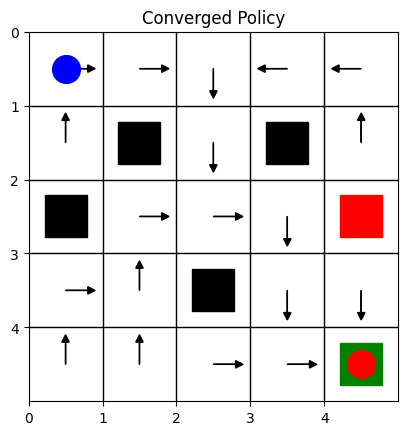

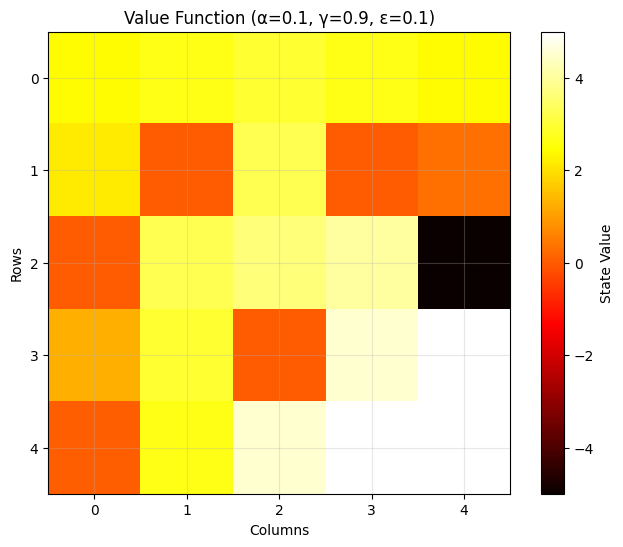

(array([[2, 2, 1, 3, 3],
        [0, 1, 1, 1, 0],
        [0, 2, 2, 1, 2],
        [2, 0, 0, 1, 1],
        [0, 0, 2, 2, 0]]),
 array([[ 2.39184194e+00,  2.65760216e+00,  2.95289129e+00,
          2.65760216e+00,  2.39137144e+00],
        [ 2.15265775e+00,  7.01071173e-04,  3.28099032e+00,
          9.28892828e-04,  3.37173074e-01],
        [ 9.66465666e-04,  3.28099032e+00,  3.64554480e+00,
          4.05060533e+00, -5.00000000e+00],
        [ 1.25352396e+00,  2.95289126e+00,  9.75595533e-04,
          4.50067259e+00,  5.00074733e+00],
        [ 4.85643945e-02,  2.65736639e+00,  4.50067259e+00,
          5.00074733e+00,  5.00000000e+00]]))

In [33]:
grid_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 5],
    'obstacle_states': [[3, 1], [2, 2], [2, 4], [4, 3]],
    'trap_state': [3, 5],
    'seed': 27
}

env = GridWorld(
                    size=grid_config['size'],
                    start=grid_config['start'],
                    goal_state=grid_config['goal_state'],
                    obstacle_states=grid_config['obstacle_states'],
                    trap_state=grid_config['trap_state'],
                    seed=grid_config['seed']
                )


agent1 = Qlearning(env, alpha=0.1, episodes=100000, seed=27, gamma=0.9, epsilon=0.1)
agent1.train(verbose=True)  # Train the agent first!
agent1.plot_policy_and_value()

### Q2 - Do it for A = 0.1, 0.5 and 0.9, take beta = 0.1.

Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.1, Epsilon: 0.1
------------------------------------------------------------
Episode  10000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  10000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  20000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  20000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  30000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  30000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  40000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  40000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  50000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  50000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  60000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  60000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  70000: Steps:   9, Reward:   5.00,

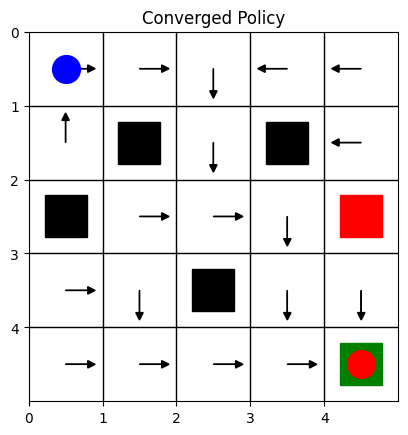

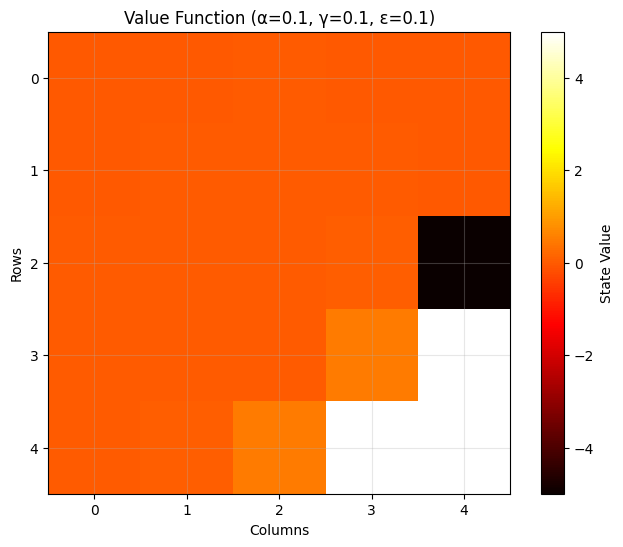

Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.5, Epsilon: 0.1
------------------------------------------------------------
Episode  10000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  10000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  20000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  20000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  30000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  30000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  40000: Steps:  12, Reward:   5.00, Success Rate: 100.00%
Episode  40000: Steps:  12, Reward:   5.00, Success Rate: 100.00%
Episode  50000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  50000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  60000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  60000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  70000: Steps:   8, Reward:   5.00,

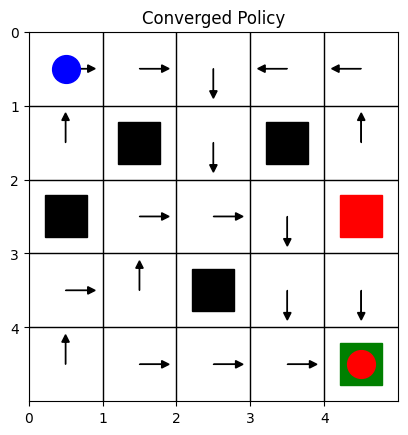

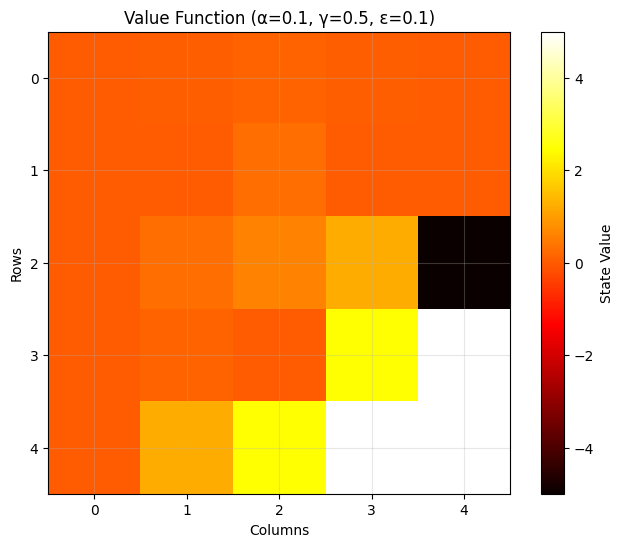

Starting Q-learning training...
Episodes: 100000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
Episode  10000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  10000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  20000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  20000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  30000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  30000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  40000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  40000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  50000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  50000: Steps:  10, Reward:   5.00, Success Rate: 100.00%
Episode  60000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  60000: Steps:   8, Reward:   5.00, Success Rate: 100.00%
Episode  70000: Steps:   8, Reward:   5.00,

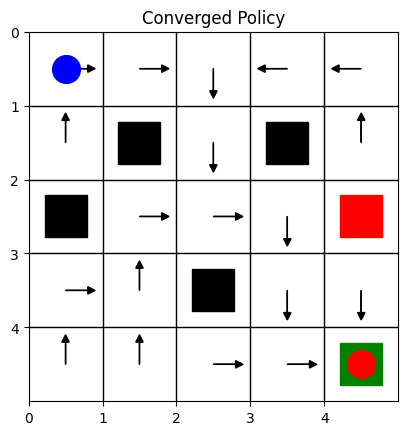

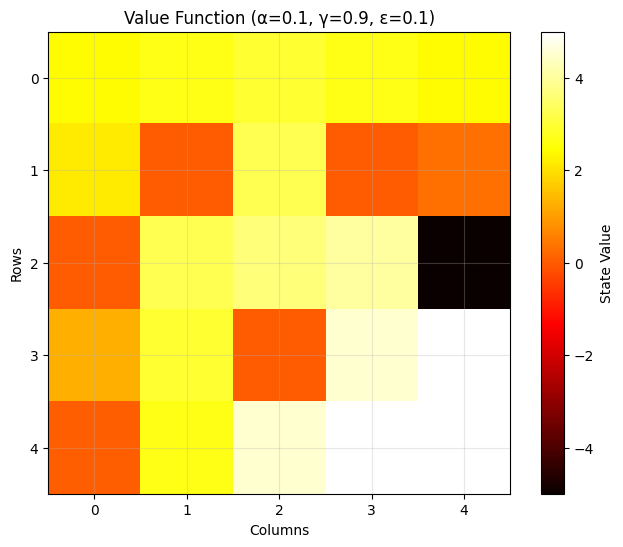

In [34]:
grid_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 5],
    'obstacle_states': [[3, 1], [2, 2], [2, 4], [4, 3]],
    'trap_state': [3, 5],
    'seed': 27
}

gammas = [0.1, 0.5, 0.9]

for gamma in gammas:

    env = GridWorld(
                        size=grid_config['size'],
                        start=grid_config['start'],
                        goal_state=grid_config['goal_state'],
                        obstacle_states=grid_config['obstacle_states'],
                        trap_state=grid_config['trap_state'],
                        seed=grid_config['seed']
                    )


    agent2 = Qlearning(env, alpha=0.1, episodes=100000, seed=27, gamma=gamma, epsilon=0.1)
    agent2.train(verbose=True)  # Train the agent first!
    agent2.plot_policy_and_value()

EPSILON COMPARISON EXPERIMENT
Gamma = 0.9
Epsilon values: [0.1, 0.3, 0.5]
Number of epochs: 20
Episodes per epoch: 100,000

Training with ε = 0.1 (γ = 0.9)
Epoch 1/20... Done
Epoch 2/20... Done
Epoch 2/20... Done
Epoch 3/20... Done
Epoch 3/20... Done
Epoch 4/20... Done
Epoch 4/20... Done
Epoch 5/20... Done
Epoch 5/20... Done
Epoch 6/20... Done
Epoch 6/20... Done
Epoch 7/20... Done
Epoch 7/20... Done
Epoch 8/20... Done
Epoch 8/20... Done
Epoch 9/20... Done
Epoch 9/20... Done
Epoch 10/20... Done
Epoch 10/20... Done
Epoch 11/20... Done
Epoch 11/20... Done
Epoch 12/20... Done
Epoch 12/20... Done
Epoch 13/20... Done
Epoch 13/20... Done
Epoch 14/20... Done
Epoch 14/20... Done
Epoch 15/20... Done
Epoch 15/20... Done
Epoch 16/20... Done
Epoch 16/20... Done
Epoch 17/20... Done
Epoch 17/20... Done
Epoch 18/20... Done
Epoch 18/20... Done
Epoch 19/20... Done
Epoch 19/20... Done
Epoch 20/20... Done
Epoch 20/20... Done
Done
Completed ε = 0.1

Training with ε = 0.3 (γ = 0.9)
Epoch 1/20... Completed ε

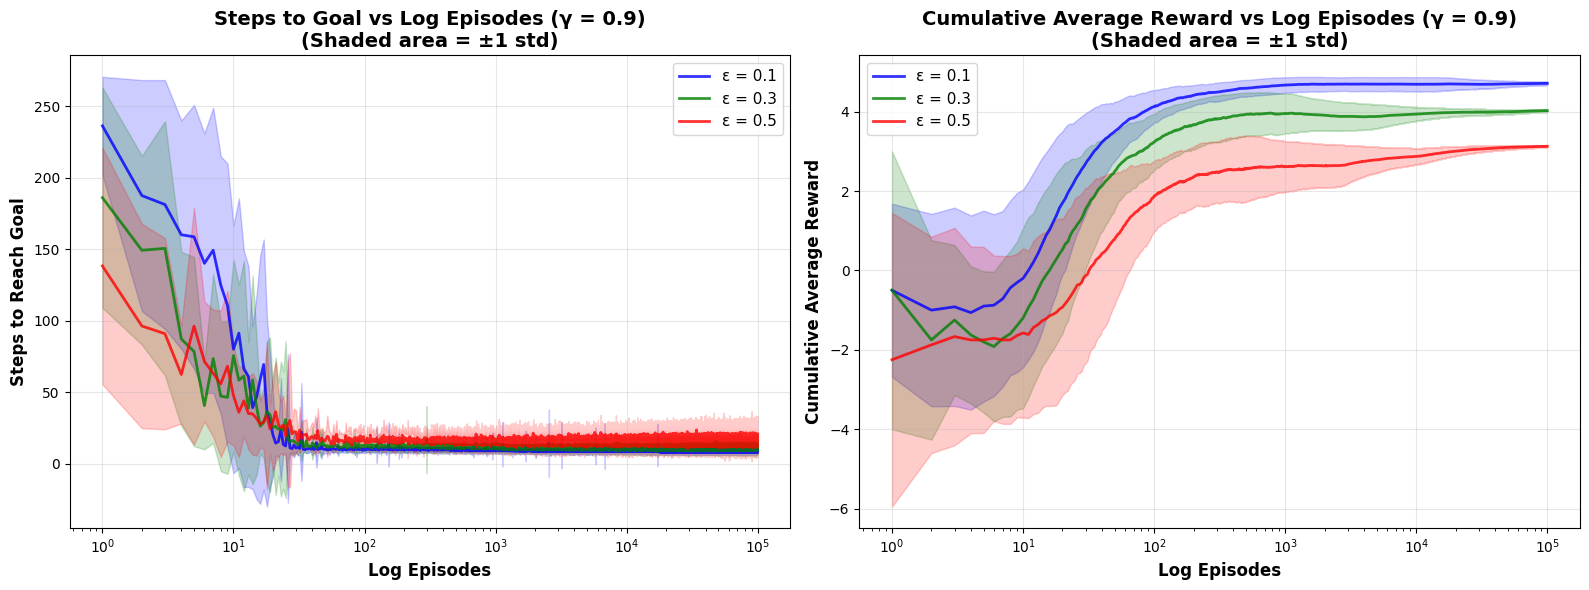

In [24]:
print("=" * 70)
print("Average Steps / Rewards over Log Episodes")
print("=" * 70)

grid_config = {
    'size': 5,
    'start': [1, 1],
    'goal_state': [5, 5],
    'obstacle_states': [[3, 1], [2, 2], [2, 4], [4, 3]],
    'trap_state': [3, 5],
    'seed': 27
}

results = Qlearning.run_multiple_epochs(
    env_config=grid_config,
    alpha=0.1,
    episodes=100000,
    gamma=0.9,
    epsilon_values=[0.1, 0.3, 0.5],
    num_epochs=20,
    verbose=True
)

print("\n" + "=" * 70)
print("EXPERIMENT COMPLETED - Generating Plots...")
print("=" * 70)

Qlearning.plot_epsilon_comparison(results, gamma=0.9, episodes=100000)


GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE


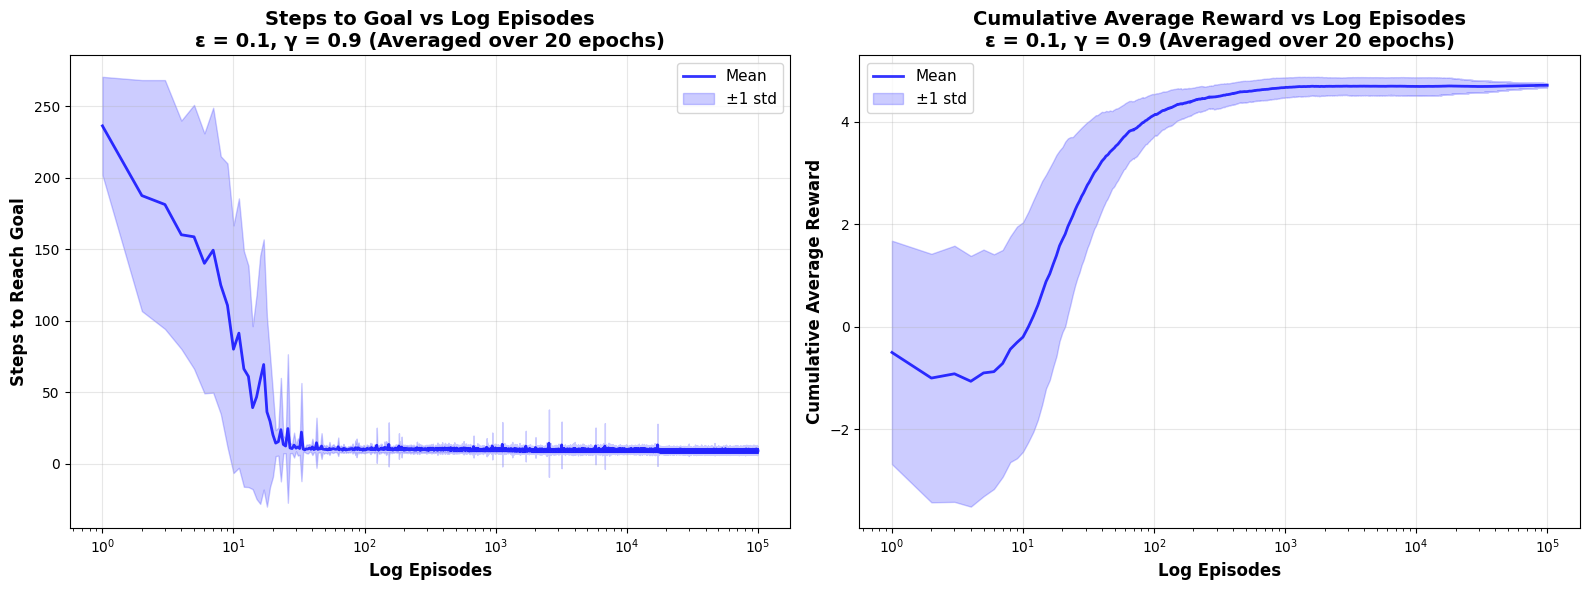


STATISTICS FOR ε = 0.1
Final Average Steps to Goal: 8.95 ± 1.43
Final Cumulative Avg Reward:  4.7117 ± 0.0402
Minimum Steps (across all episodes): 7.80
Maximum Cumulative Reward: 4.7117



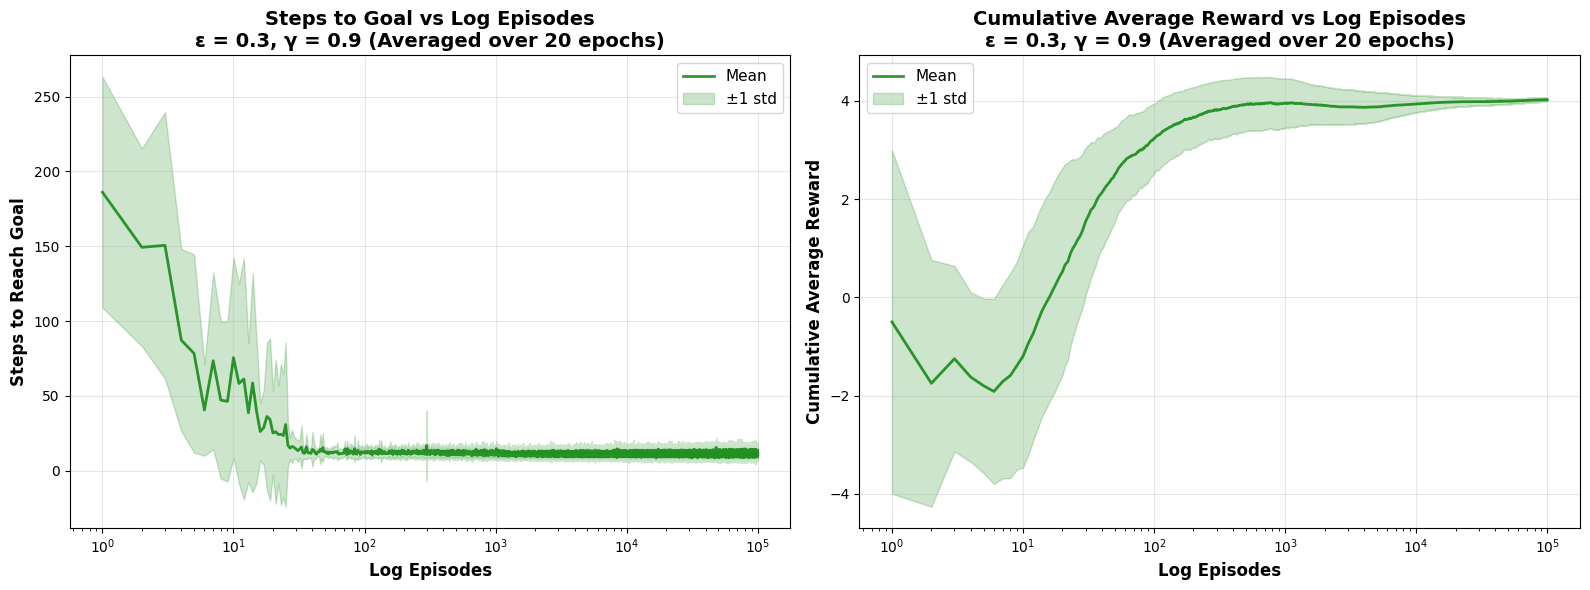


STATISTICS FOR ε = 0.3
Final Average Steps to Goal: 11.30 ± 3.16
Final Cumulative Avg Reward:  4.0260 ± 0.0344
Minimum Steps (across all episodes): 8.55
Maximum Cumulative Reward: 4.0260



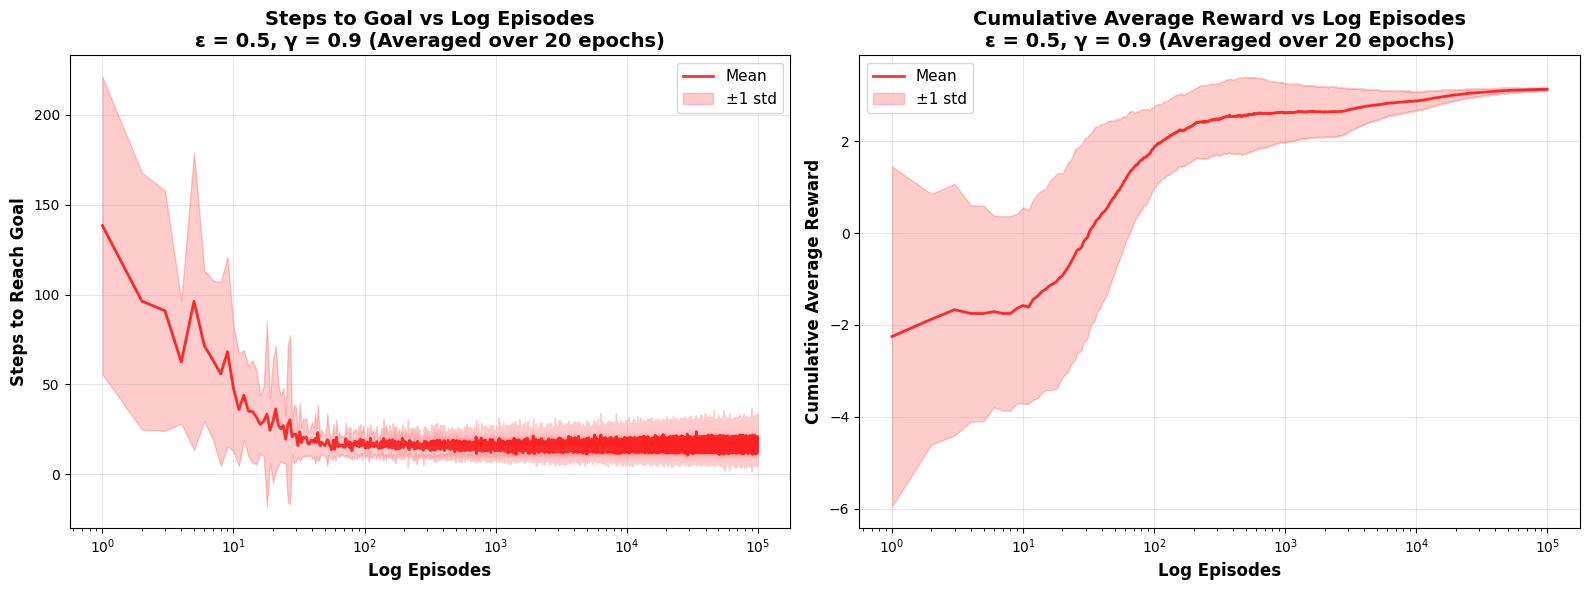


STATISTICS FOR ε = 0.5
Final Average Steps to Goal: 15.85 ± 4.59
Final Cumulative Avg Reward:  3.1274 ± 0.0253
Minimum Steps (across all episodes): 10.50
Maximum Cumulative Reward: 3.1274



In [26]:
print("\n" + "=" * 70)
print("GENERATING SEPARATE PLOTS FOR EACH EPSILON VALUE")
print("=" * 70)

Qlearning.plot_epsilon_separate(results, gamma=0.9, episodes=100000)

## Part 2

### Q1 - Plot the converged policy and value function for this grid world. Use softmax function for action selection.

In [ ]:
class BridgeGridWorld(GridWorld):
    def __init__(self, size, start, goal_state, obstacle_states, trap_state, seed, bridge_connection, bridge_state):
        super().__init__(size, start, goal_state, obstacle_states, trap_state, seed)
        self.bridge_connection = bridge_connection
        self.bridge_state = bridge_state

    


In [24]:
import numpy as np
import matplotlib.pyplot as plt

class BridgeGridWorld(GridWorld):
    def __init__(self, size, start, goal_state, obstacle_states, trap_state, seed, bridge_state):
        """
        A two-part GridWorld connected by a single bridge column.
        - The grid is size x (2*size + 1)
        - The bridge column (col=bridge_state[1]) has walls in all rows except the bridge cell.
        - Hitting a wall or going outside gives -1 reward.
        """
        super().__init__(size, start, goal_state, obstacle_states, trap_state, seed)
        self.bridge_state = bridge_state
        self.bridge_col = bridge_state[1]
        self.total_cols = size * 2 + 1
        
        # Override size to represent total number of columns for state calculations
        self.grid_rows = self.size  # Keep original rows
        self.grid_cols = self.total_cols  # Total columns including bridge

        # Explicitly define wall coordinates (entire bridge column except bridge)
        self.walls = [[r, self.bridge_col] for r in range(1, self.grid_rows + 1)
                      if [r, self.bridge_col] != self.bridge_state]

    def is_valid_state(self, state):
        row, col = state

        # Out of total boundary (5x11 world)
        if row < 1 or row > self.grid_rows or col < 1 or col > self.grid_cols:
            return False

        # Wall check (column 6 except bridge)
        if state in self.walls:
            return False

        # Obstacles
        if state in self.obstacles:
            return False

        return True

    def step(self, action):
        current_state = self.state

        # Define action directions
        if action == 'N':
            next_state = [current_state[0] - 1, current_state[1]]
        elif action == 'S':
            next_state = [current_state[0] + 1, current_state[1]]
        elif action == 'E':
            next_state = [current_state[0], current_state[1] + 1]
        elif action == 'W':
            next_state = [current_state[0], current_state[1] - 1]
        else:
            raise ValueError("Invalid action")

        # --- Bridge transitions ---
        # Only allowed horizontally via the bridge
        if current_state == [self.bridge_state[0], self.bridge_state[1] - 1] and action == 'E':
            next_state = self.bridge_state
        elif current_state == [self.bridge_state[0], self.bridge_state[1] + 1] and action == 'W':
            next_state = self.bridge_state
        elif current_state == self.bridge_state and action == 'E':
            next_state = [self.bridge_state[0], self.bridge_state[1] + 1]
        elif current_state == self.bridge_state and action == 'W':
            next_state = [self.bridge_state[0], self.bridge_state[1] - 1]

        # --- Validation ---
        if self.is_valid_state(next_state):
            self.state = next_state
            reward = self.get_reward(self.state)
        else:
            reward = -1  # wall or boundary penalty
            next_state = self.state

        is_terminal = self.is_terminal_state(next_state)
        return self.state, reward, is_terminal

    def plot_grid(self, policy=None, plot_policy_flag=False):
        """
        Extend plotter to show explicit wall column (bridge col walls).
        """
        plt.figure(figsize=(8, 5))
        ax = plt.gca()
        total_size = self.grid_cols

        # Draw gridlines
        for i in range(1, total_size):
            ax.axhline(i, color='gray', linestyle='-', linewidth=0.5)
            ax.axvline(i, color='gray', linestyle='-', linewidth=0.5)

        # Start, goal, trap
        ax.plot(self.start[1] - 0.5, self.start[0] - 0.5, 'bo', markersize=20, label='Start')
        ax.plot(self.goal[1] - 0.5, self.goal[0] - 0.5, 'gs', markersize=25, label='Goal')
        ax.plot(self.trap[1] - 0.5, self.trap[0] - 0.5, 'rs', markersize=25, label='Trap')

        # Obstacles (black)
        for obs in self.obstacles:
            ax.plot(obs[1] - 0.5, obs[0] - 0.5, 'ks', markersize=25)

        # Bridge walls (gray)
        for wall in self.walls:
            ax.plot(wall[1] - 0.5, wall[0] - 0.5, 's', color='lightgray', markersize=25)

        # Current state
        ax.plot(self.state[1] - 0.5, self.state[0] - 0.5, 'ro', markersize=15)

        # Optional policy arrows
        if plot_policy_flag and policy is not None:
            self.plot_policy_arrows(policy, self.start)

        ax.set_xlim([0, total_size])
        ax.set_ylim([self.grid_rows, 0])
        ax.set_xticks(np.arange(total_size))
        ax.set_yticks(np.arange(self.grid_rows))
        ax.grid(True)
        ax.set_aspect('equal')
        plt.title("Bridge GridWorld")
        plt.show()

    def plot_policy_arrows(self, policy, start):
        """Override to handle the larger grid dimensions."""
        for i in range(self.grid_rows):
            for j in range(self.grid_cols):
                state_pos = [i + 1, j + 1]
                # Skip goal, trap, obstacles, and walls
                if (state_pos != self.goal and state_pos != self.trap and 
                    state_pos not in self.obstacles and state_pos not in self.walls):
                    
                    action = policy[i, j]
                    if action == 0:  # North
                        dx, dy = 0, -0.3
                    elif action == 1:  # South
                        dx, dy = 0, 0.3
                    elif action == 2:  # East
                        dx, dy = 0.3, 0
                    elif action == 3:  # West
                        dx, dy = -0.3, 0
                    else:
                        continue

                    plt.arrow(j + 0.5, i + 0.5, dx, dy, head_width=0.1, head_length=0.1, fc='k', ec='k')
        plt.title('Converged Policy')


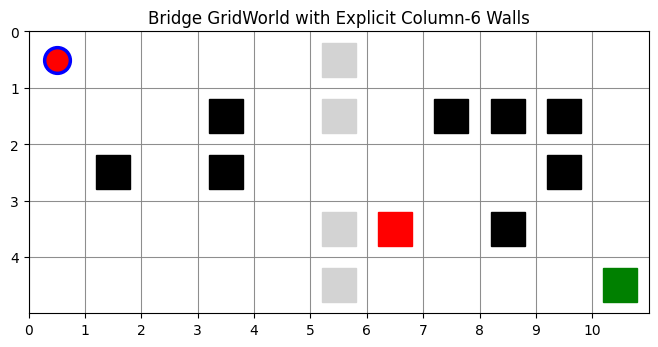

In [13]:
# Bridge setup based on your image
bridge_state = [3, 6]
bridge_connection = {'left': [3, 5], 'right': [3, 7]}

# Example obstacles from the image (you can fill exact coordinates)
obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=42,
    bridge_state=bridge_state
)

env.reset()
env.plot_grid()


In [25]:
# Bridge setup based on your image
bridge_state = [3, 6]

# Example obstacles from the image (you can fill exact coordinates)
obstacles = [[3, 2], [2, 4], [3, 4], [4, 9], [2, 8], [2, 9], [2, 10], [3, 10]]

env = BridgeGridWorld(
    size=5,
    start=[1, 1],
    goal_state=[5, 11],
    obstacle_states=obstacles,
    trap_state=[4, 7],
    seed=42,
    bridge_state=bridge_state
)

agent1 = Qlearning(env, alpha=0.1, episodes=200000, seed=27, gamma=0.9, epsilon=0.1)
agent1.train(verbose=True, softmax=True)
agent1.plot_policy_and_value()

Starting Q-learning training...
Episodes: 200000, Learning Rate: 0.1
Discount Factor: 0.9, Epsilon: 0.1
------------------------------------------------------------
Episode  20000: Steps: 250, Reward: -86.00, Success Rate: 0.00%
Episode  20000: Steps: 250, Reward: -86.00, Success Rate: 0.00%
Episode  40000: Steps: 203, Reward: -157.00, Success Rate: 0.00%
Episode  40000: Steps: 203, Reward: -157.00, Success Rate: 0.00%
Episode  60000: Steps: 250, Reward: -54.00, Success Rate: 0.00%
Episode  60000: Steps: 250, Reward: -54.00, Success Rate: 0.00%
Episode  80000: Steps: 250, Reward: -93.00, Success Rate: 0.00%
Episode  80000: Steps: 250, Reward: -93.00, Success Rate: 0.00%


KeyboardInterrupt: 